In [1]:
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from movement.io.load_poses import from_file 
import os 

### Generation skeleton plots for methods 

In [4]:
dataset_path = "/Users/thomasbush/Documents/Vault/Iurilli_lab/3d_tracking/data/multicam_video_2024-07-22T10_19_22_cropped_20250325101012/multicam_video_2024-07-22T10_19_22_centralpredictions.slp"

data = from_file(dataset_path, source_software="SLEAP")

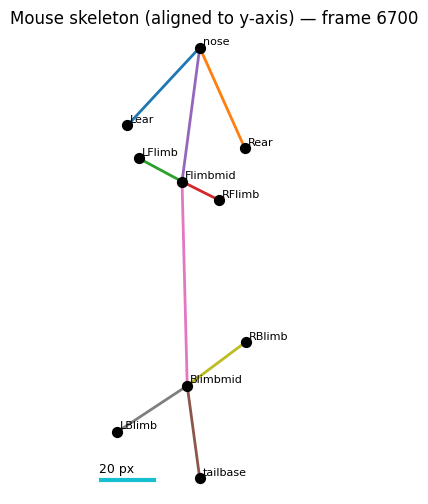

In [40]:
import matplotlib.pyplot as plt
import numpy as np

# Keypoint names and skeleton connections as index pairs
keypoint_names = ['nose', 'Lear', 'Rear', 'LFlimb', 'RFlimb', 'Flimbmid',
                  'LBlimb', 'RBlimb', 'Blimbmid', 'tailbase']
keypoint_indices = {name: idx for idx, name in enumerate(keypoint_names)}

skeleton_connections = [
    (0, 1),  # nose - Lear
    (0, 2),  # nose - Rear
    # (0, 3),  # nose - LFlimb
    # (0, 4),  # nose - RFlimb
    (3, 5),  # LFlimb - Flimbmid
    (4, 5),  # RFlimb - Flimbmid
    (5, 0),  # Flimbmid - nose
    # (0, 9),  # nose - tailbase
    # (0, 8),  # nose - Blimbmid                                                                                                      
    (8, 9),  # Blimbmid - tailbase
    (5, 8),  # Flimbmid - Blimbmid
    # (6, 7),  # LBlimb - RBlimb
    (6, 8),  # LBlimb - Blimbmid
    (7, 8),  # RBlimb - Blimbmid
    # (6, 9),  # LBlimb - tailbase
    # (7, 9),  # RBlimb - tailbase
]

def _rotmat(theta: float) -> np.ndarray:
    """2D rotation matrix for angle theta (radians)."""
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def plot_mouse_skeleton_vertical(
    position_arr,
    frame_num: int = 0,
    individual_idx: int = 0,
    ax=None,
    *,
    align_axis: str = "y",          # "y" (vertical) or "x" (horizontal)
    nose_up: bool = True,           # enforce nose above tail after alignment
    center_on: str = "midpoint",    # "midpoint" (nose-tail midpoint) or "tailbase"
    show_labels: bool = True,
    label_offset: float = 1.0,
    point_size: float = 50,
    line_width: float = 2.0,
    pad: float = 5.0,               # padding around min/max for axis limits
    fixed_limits: tuple | None = None,  # e.g. (-40, 40, -60, 60) for (xmin,xmax,ymin,ymax)
    show_axes: bool = False,
    add_scalebar: bool = False,
    scalebar_length: float = 20.0,  # in the same units as your coordinates
    scalebar_label: str = "20 px",
):
    """
    Vertical thesis-friendly skeleton plot.

    position_arr: np.ndarray of shape (num_frames, 2, num_keypoints, num_individuals)
    """

    coords = position_arr[frame_num, :, :, individual_idx]  # shape (2, K)
    K = coords.shape[1]

    nose = coords[:, keypoint_indices["nose"]]
    tail = coords[:, keypoint_indices["tailbase"]]

    # --- Centering ---
    if center_on == "midpoint":
        center = (nose + tail) / 2
    elif center_on == "tailbase":
        center = tail
    else:
        raise ValueError("center_on must be 'midpoint' or 'tailbase'")

    coords_centered = coords - center[:, None]

    # --- Alignment ---
    # Vector from tail -> nose
    v = nose - tail
    angle = np.arctan2(v[1], v[0])  # orientation w.r.t. +x

    # First rotate so tail->nose lies on +x axis:
    R_to_x = _rotmat(-angle)
    coords_aligned = R_to_x @ coords_centered

    # If requested vertical alignment, rotate +90° so +x becomes +y
    if align_axis.lower() == "y":
        coords_aligned = _rotmat(np.pi / 2) @ coords_aligned
    elif align_axis.lower() != "x":
        raise ValueError("align_axis must be 'x' or 'y'")

    # Enforce nose "up" (positive y) after alignment (useful for consistent figures)
    if nose_up:
        nose_after = coords_aligned[:, keypoint_indices["nose"]]
        tail_after = coords_aligned[:, keypoint_indices["tailbase"]]
        # If nose is below tail, flip vertically (multiply y by -1)
        if nose_after[1] < tail_after[1]:
            coords_aligned[1, :] *= -1

    # --- Plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(4, 6) if align_axis == "y" else (6, 4))

    # connections first (under points)
    for i, j in skeleton_connections:
        ax.plot([coords_aligned[0, i], coords_aligned[0, j]],
                [coords_aligned[1, i], coords_aligned[1, j]],
                linewidth=line_width, zorder=2)

    # keypoints
    ax.scatter(coords_aligned[0], coords_aligned[1], s=point_size, color="black", zorder=3)

    # labels
    if show_labels:
        for idx, name in enumerate(keypoint_names[:K]):
            ax.text(coords_aligned[0, idx] + label_offset,
                    coords_aligned[1, idx] + label_offset,
                    name, fontsize=8, zorder=4)

    # axis formatting
    ax.set_aspect("equal", adjustable="datalim")
    ax.set_title(f"Mouse skeleton (aligned to {align_axis}-axis) — frame {frame_num}")

    # limits
    if fixed_limits is not None:
        xmin, xmax, ymin, ymax = fixed_limits
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
    else:
        xmin, xmax = coords_aligned[0].min() - pad, coords_aligned[0].max() + pad
        ymin, ymax = coords_aligned[1].min() - pad, coords_aligned[1].max() + pad
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)

    # optional scalebar (simple)
    if add_scalebar:
        x0 = ax.get_xlim()[0] + pad
        y0 = ax.get_ylim()[0] + pad
        ax.plot([x0, x0 + scalebar_length], [y0, y0], linewidth=3, solid_capstyle="butt")
        ax.text(x0, y0 + pad * 0.3, scalebar_label, fontsize=9, va="bottom")

    if not show_axes:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    return ax

# Example usage:
num_frames = data.position.values.shape[0]
mid_frame = num_frames // 2
plot_mouse_skeleton_vertical(data.position.values, frame_num=6700,
                             align_axis="y", nose_up=True,
                             fixed_limits=(-40, 50, -80, 80),
                             add_scalebar=True, scalebar_length=20, scalebar_label="20 px")
plt.savefig("/Users/thomasbush/Downloads/central_mouse_skeleton_vertical.svg", dpi=300, bbox_inches="tight")
plt.show()


In [42]:
side_data.keypoints.values


array(['nose', 'Lear', 'Rear', 'LFlimb', 'RFlimb', 'FLimbMid', 'LBlimb',
       'RBlimb', 'BLimbMid', 'tailbase', 'UpperForward', 'UpperMid',
       'UpperBack'], dtype='<U12')

In [ ]:
# script to generate plot for side views 
side_path_view = "/Users/thomasbush/Documents/Vault/Iurilli_lab/3d_tracking/data/multicam_video_2024-07-22T10_19_22_cropped_20250325101012/multicam_video_2024-07-22T10_19_22_mirror-bottompredictions.slp"

side_data = from_file(side_path_view, source_software="SLEAP")

keypoint_names = [
    'nose', 'Lear', 'Rear', 'LFlimb', 'RFlimb', 'FLimbMid', 'LBlimb',
    'RBlimb', 'BLimbMid', 'tailbase', 'UpperForward', 'UpperMid', 'UpperBack'
]
keypoint_indices = {name: idx for idx, name in enumerate(keypoint_names)}

    # (7, 9),  # RBlimb - tailbase


In [69]:

skeleton_connections = [
    (0, 1),    # nose - Lear
    (0, 2),    # nose - Rear
    (1, 2),
    # (0, 3),    # nose - LFlimb
    # (0, 4),    # nose - RFlimb
    (1, 10),
    (2, 10),
    (3, 5),    # LFlimb - FLimbMid
    (4, 5),    # RFlimb - FLimbMid
    (5, 0),    # FLimbMid - nose
    (8, 9),    # BLimbMid - tailbase
    (5, 8),    # FLimbMid - BLimbMid
    (6, 8),    # LBlimb - BLimbMid
    (7, 8),    # RBlimb - BLimbMid
    # (6, 9),    # LBlimb - tailbase
    # (7, 9),    # RBlimb - tailbase
    # (9, 10),   # tailbase - UpperForward
    (10, 11),  # UpperForward - UpperMid
    (11, 12),  # UpperMid - UpperBack
    (10, 5),   # UpperForward - FLimbMid      # connect upper forward to front mid
    (11, 8),   # UpperMid - BLimbMid          # connect upper mid to back mid
    (12, 8),   # UpperBack - BLimbMid         # connect upper back to back mid
    (8, 6),    # BLimbMid - LBlimb            # connect back mid to left back limb
    (8, 7),    # BLimbMid - RBlimb            # connect back mid to right back limb
    (5, 3),    # FLimbMid - LFlimb            # (already connected, left for clarity)
    (5, 4),    # FLimbMid - RFlimb            # (already connected, left for clarity)
    (5, 8),    # FLimbMid - BLimbMid          # connect the two mid points (redundant, already included)
    (10, 3),   # UpperForward - LFlimb        # connect upper forward to left front limb
    (10, 4),   # UpperForward - RFlimb   
    (9, 12) , 
    (12, 6),
    (12, 7)    # connect upper forward to right front limb
]

In [74]:

def _rotmat(theta: float) -> np.ndarray:
    c, s = np.cos(theta), np.sin(theta)
    return np.array([[c, -s],
                     [s,  c]])

def plot_mouse_skeleton_sideview(
    position_arr,
    frame_num: int = 0,
    individual_idx: int = 0,
    ax=None,
    *,
    keypoint_indices=None,
    keypoint_names=None,
    skeleton_connections=None,
    center_on: str = "tailbase",     # "tailbase" or "midpoint"
    tail_to_nose_on_x: bool = True,  # align tail->nose to +X
    nose_right: bool = True,         # enforce nose is on +X side
    enforce_up: bool = True,         # try to make dorsal/back "up" (+Y)
    up_strategy: str = "upperchain", # "upperchain" or "blimbmid" or "none"
    show_labels: bool = True,
    label_offset: float = 2.0,
    point_size: float = 40,
    line_width: float = 2.0,
    pad: float = 10.0,
    fixed_limits: tuple | None = None,  # (xmin,xmax,ymin,ymax)
    show_axes: bool = False,
    title: str | None = None,
):
    """
    Side-view canonical skeleton:
    - aligns tail->nose to +X
    - optionally enforces dorsal/back points to be +Y (up)

    position_arr: np.ndarray of shape (num_frames, 2, num_keypoints, num_individuals)
    """

    import numpy as np
    import matplotlib.pyplot as plt

    if keypoint_indices is None or keypoint_names is None or skeleton_connections is None:
        raise ValueError("Pass keypoint_indices, keypoint_names, skeleton_connections for your side-view set.")

    coords = position_arr[frame_num, :, :, individual_idx]  # (2, K)

    # Defensive: nan-aware versions for center references
    try:
        nose = coords[:, keypoint_indices["nose"]]
    except Exception:
        nose = np.full((2,), np.nan)
    try:
        tail = coords[:, keypoint_indices["tailbase"]]
    except Exception:
        tail = np.full((2,), np.nan)

    # --- center ---
    if center_on == "tailbase":
        center = tail
    elif center_on == "midpoint":
        center = 0.5 * (nose + tail)
    else:
        raise ValueError("center_on must be 'tailbase' or 'midpoint'")

    coords_c = coords - center[:, None]

    # --- rotate so tail->nose aligns to +X ---
    if tail_to_nose_on_x:
        v = nose - tail
        if np.any(np.isnan(v)):
            ang = 0.0
        else:
            ang = np.arctan2(v[1], v[0])  # angle vs +X
        R = _rotmat(-ang)
        coords_r = R @ coords_c
    else:
        coords_r = coords_c

    # --- enforce nose to the right (+X) ---
    if nose_right:
        try:
            nose_after = coords_r[:, keypoint_indices["nose"]]
            tail_after = coords_r[:, keypoint_indices["tailbase"]]
            if not (np.any(np.isnan(nose_after)) or np.any(np.isnan(tail_after))):
                if nose_after[0] < tail_after[0]:
                    coords_r[0, :] *= -1  # mirror horizontally
        except Exception:
            pass

    # --- enforce a consistent "up" direction (+Y) ---
    if enforce_up and up_strategy != "none":
        if up_strategy == "upperchain":
            needed = ["UpperForward", "UpperBack"]
            if all(k in keypoint_indices for k in needed):
                try:
                    uf = coords_r[:, keypoint_indices["UpperForward"]]
                    ub = coords_r[:, keypoint_indices["UpperBack"]]
                    if not (np.any(np.isnan(uf)) or np.any(np.isnan(ub))):
                        dorsal_vec = ub - uf
                        if dorsal_vec[1] < 0:
                            coords_r[1, :] *= -1
                except Exception:
                    pass
        elif up_strategy == "blimbmid":
            if "BLimbMid" in keypoint_indices:
                try:
                    bl = coords_r[:, keypoint_indices["BLimbMid"]]
                    tb = coords_r[:, keypoint_indices["tailbase"]]
                    if not (np.any(np.isnan(bl)) or np.any(np.isnan(tb))):
                        if bl[1] < tb[1]:
                            coords_r[1, :] *= -1
                except Exception:
                    pass
        else:
            raise ValueError("up_strategy must be 'upperchain', 'blimbmid', or 'none'")

    # ---- ROTATE SKELETON 180° ----
    coords_r = _rotmat(np.pi) @ coords_r  # rotate all points 180 degrees

    # --- plot ---
    if ax is None:
        fig, ax = plt.subplots(figsize=(6, 4))

    # connections (skip if either endpoint is nan)
    for i, j in skeleton_connections:
        p1 = coords_r[:, i]
        p2 = coords_r[:, j]
        if np.any(np.isnan(p1)) or np.any(np.isnan(p2)):
            continue
        ax.plot([p1[0], p2[0]],
                [p1[1], p2[1]],
                linewidth=line_width, zorder=2)

    # keypoints (skip nans in .scatter)
    x_valid = coords_r[0]
    y_valid = coords_r[1]
    valid_mask = ~(np.isnan(x_valid) | np.isnan(y_valid))
    ax.scatter(x_valid[valid_mask], y_valid[valid_mask], s=point_size, color="black", zorder=3)

    if show_labels:
        for idx, name in enumerate(keypoint_names):
            x = coords_r[0, idx]
            y = coords_r[1, idx]
            if np.isnan(x) or np.isnan(y):
                continue
            ax.text(x + label_offset,
                    y + label_offset,
                    name, fontsize=8, zorder=4)

    ax.set_aspect("equal", adjustable="datalim")

    if title is None:
        title = f"Side view (tail→nose on +X) — frame {frame_num}"
    ax.set_title(title)

    # limits
    if fixed_limits is not None:
        xmin, xmax, ymin, ymax = fixed_limits
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
    else:
        # Only use finite values for limits, else skip setting limits
        finite_x = coords_r[0][np.isfinite(coords_r[0])]
        finite_y = coords_r[1][np.isfinite(coords_r[1])]
        if len(finite_x) > 0 and len(finite_y) > 0:
            xmin, xmax = finite_x.min() - pad, finite_x.max() + pad
            ymin, ymax = finite_y.min() - pad, finite_y.max() + pad
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
        # else: leave default

    if not show_axes:
        ax.set_xticks([])
        ax.set_yticks([])
        for spine in ax.spines.values():
            spine.set_visible(False)

    return ax


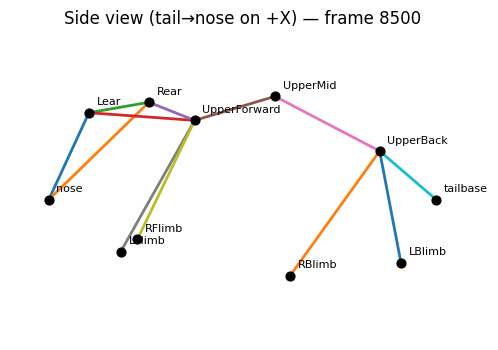

In [75]:
pos = side_data.position.values
mid_frame = pos.shape[0] // 2

plot_mouse_skeleton_sideview(
    pos,
    frame_num=8500,
    individual_idx=0,
    keypoint_indices=keypoint_indices,
    keypoint_names=keypoint_names,
    skeleton_connections=skeleton_connections,
    center_on="tailbase",
    nose_right=True,
    enforce_up=True,
    up_strategy="upperchain",  # uses UpperForward/UpperBack to decide what's "up"
    fixed_limits=None,         # or set (xmin,xmax,ymin,ymax) for consistent multi-panel figs
)
plt.savefig("/Users/thomasbush/Downloads/side_mouse_skeleton_sideview.svg", dpi=300, bbox_inches="tight")
plt.show()


### Figures for the triangulation 

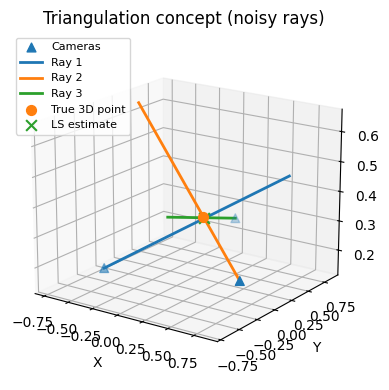

P_true: [0.2  0.1  0.35]
P_est : [0.20108941 0.10340323 0.34869416]


In [76]:


def normalize(v):
    v = np.asarray(v, dtype=float)
    return v / np.linalg.norm(v)

# --- 1) Define geometry ---
P_true = np.array([0.20, 0.10, 0.35])

C1 = np.array([-0.60, -0.20, 0.15])
C2 = np.array([ 0.70, -0.10, 0.20])
C3 = np.array([ 0.00,  0.85, 0.25])

d1 = normalize((P_true - C1) + np.array([0.00,  0.01, -0.005]))
d2 = normalize((P_true - C2) + np.array([-0.01, 0.00,  0.006]))
d3 = normalize((P_true - C3) + np.array([0.008,-0.01, 0.00]))

Cs = np.stack([C1, C2, C3], axis=0)
ds = np.stack([d1, d2, d3], axis=0)

# --- 2) Least-squares "closest point to multiple lines" ---
# Minimize sum_i ||(I - d_i d_i^T)(x - C_i)||^2
A = np.zeros((3, 3))
b = np.zeros(3)
I = np.eye(3)
for C, d in zip(Cs, ds):
    P = I - np.outer(d, d)
    A += P
    b += P @ C

P_est = np.linalg.solve(A, b)

# --- 3) Make ray segments for plotting ---
ts = np.linspace(0.0, 1.6, 50)  # length of rays in plot
rays = [C[None, :] + ts[:, None] * d[None, :] for C, d in zip(Cs, ds)]

# --- 4) Plot ---
fig = plt.figure(figsize=(5, 4))
ax = fig.add_subplot(111, projection="3d")

# cameras
ax.scatter(Cs[:,0], Cs[:,1], Cs[:,2], s=40, marker="^", label="Cameras")

# rays
for i, ray in enumerate(rays, start=1):
    ax.plot(ray[:,0], ray[:,1], ray[:,2], linewidth=2, label=f"Ray {i}")

# points
ax.scatter([P_true[0]], [P_true[1]], [P_true[2]], s=50, marker="o", label="True 3D point")
ax.scatter([P_est[0]],  [P_est[1]],  [P_est[2]],  s=60, marker="x", label="LS estimate")

# optional: draw a small segment from estimate to each ray (shows residual)
def closest_point_on_line(C, d, x):
    t = np.dot(d, (x - C))
    return C + t * d

for C, d in zip(Cs, ds):
    q = closest_point_on_line(C, d, P_est)
    ax.plot([P_est[0], q[0]], [P_est[1], q[1]], [P_est[2], q[2]], linestyle="--", linewidth=1)

ax.set_xlabel("X")
ax.set_ylabel("Y")
ax.set_zlabel("Z")
ax.set_title("Triangulation concept (noisy rays)")

# make it look “diagram-like”
ax.view_init(elev=18, azim=-55)
ax.set_box_aspect([1, 1, 0.8])
ax.legend(loc="upper left", fontsize=8)

plt.tight_layout()
plt.show()

print("P_true:", P_true)
print("P_est :", P_est)
